In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

market = pd.read_csv("../data/market_master.csv")

market["Date"] = pd.to_datetime(market["Date"])
market = market.set_index("Date")

In [2]:
market["rolling_max"] = market["nifty_close"].cummax()

market["drawdown"] = (
    market["nifty_close"] - market["rolling_max"]
) / market["rolling_max"]

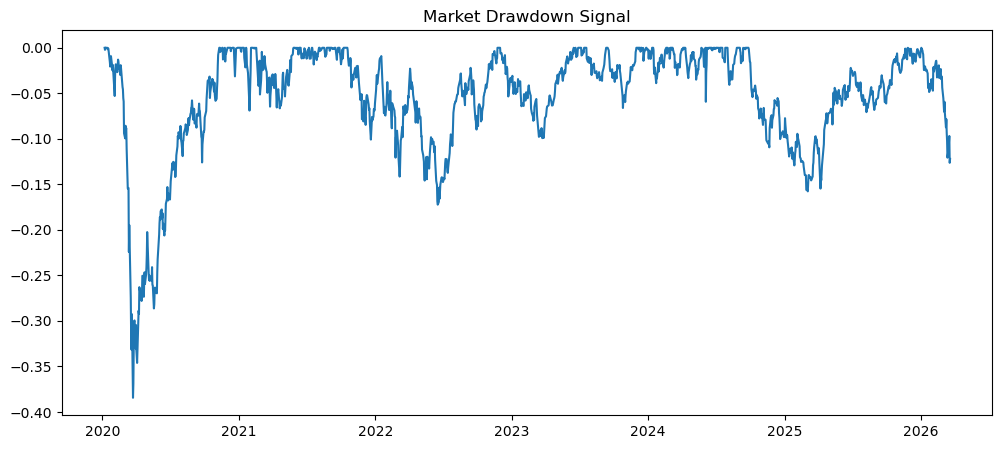

In [3]:
market["dd_signal"] = market["drawdown"].rolling(5).mean()

market["dd_regime"] = np.where(
    market["drawdown"] < -0.2, -1,   # crash
    np.where(market["drawdown"] < -0.1, 0, 1)  # recovery / normal
)
plt.figure(figsize=(12,5))
plt.plot(market.index, market["drawdown"])
plt.title("Market Drawdown Signal")
plt.show()

In [4]:
market = market.dropna()

market.to_csv("../data/market_master.csv")